<div style="display: flex; background-color: RGB(255,114,0);" >
<h1 style="margin: auto; padding: 30px; ">Analysez les ventes d'une librairie avec Python: analyse des indicateurs de ventes</h1>
</div>

# OBJECTIF DE CE NOTEBOOK

Ce notebook analyse les ventes d'une librairie en ligne sur la période 2021-2023. 

**Objectifs :**
- Explorer et nettoyer les données transactionnelles (transactions, clients, produits)
- Calculer les indicateurs clés de performance (CA, panier moyen, fréquence d'achat)
- Analyser les tendances temporelles (CA journalier, moyennes mobiles, KPIs mensuels)
- Étudier la répartition du CA par catégorie et identifier les produits clés (Pareto 80/20)
- Identifier et profiler les 4 clients BtoB
- Mesurer la concentration des ventes (courbe de Lorenz, coefficient de Gini)

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des données</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.1 - Importation des librairies</h3>
</div>

In [1]:
# IMPORTS DE BASE
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# VISUALISATION
import matplotlib.pyplot as plt
import seaborn as sns

# STATISTIQUES
from scipy import stats


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.2 - Chargements des fichiers</h3>
</div>

In [2]:
# Chargement des trois fichiers
transactions = pd.read_csv('Transactions.csv', sep=';')
transactions = transactions.dropna(how='all')  # Supprimer 361K lignes vides (padding Excel)
customers = pd.read_csv('customers.csv', sep=';')
products = pd.read_csv('products.csv', sep=';')

print("✓ Fichiers chargés avec succès!")


✓ Fichiers chargés avec succès!


In [3]:
# Vérification chargement et des dimensions

print(f"Transactions: {transactions.shape} - {transactions.shape[0]} lignes, {transactions.shape[1]} colonnes")
print(f"Customers: {customers.shape}")
print(f"Products: {products.shape}")


Transactions: (687534, 4) - 687534 lignes, 4 colonnes
Customers: (8621, 3)
Products: (3286, 3)


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1 - Analyse exploratoire détaillée des données: Transactions</h3>
</div>

In [4]:
# --- Exploration du fichier Transactions ---
# Objectif : comprendre la structure, les types, les volumes et détecter d'éventuelles anomalies
# (valeurs extrêmes, doublons, formats incohérents) avant la fusion des tables.
print("=== TRANSACTIONS ===")
print(transactions.info())       # Types et valeurs non-nulles par colonne
print("\nPremières lignes:")
print(transactions.head(10))     # Aperçu visuel des premières entrées
print("\nDernières lignes:")
print(transactions.tail())       # Vérifier la cohérence en fin de fichier
print("\nTypes de données:")
print(transactions.dtypes)
print("\nStatistiques:")
print(transactions.describe())   # Min/max/mean pour détecter les outliers potentiels


=== TRANSACTIONS ===
<class 'pandas.core.frame.DataFrame'>
Index: 687534 entries, 0 to 687533
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   id_prod     687534 non-null  object
 1   date        687534 non-null  object
 2   session_id  687534 non-null  object
 3   client_id   687534 non-null  object
dtypes: object(4)
memory usage: 26.2+ MB
None

Premières lignes:
  id_prod                        date session_id client_id
0  0_1259  2021-03-01 00:01:07.843138        s_1     c_329
1  0_1390  2021-03-01 00:02:26.047414        s_2     c_664
2  0_1352  2021-03-01 00:02:38.311413        s_3     c_580
3  0_1458  2021-03-01 00:04:54.559692        s_4    c_7912
4  0_1358  2021-03-01 00:05:18.801198        s_5    c_2033
5  0_1073  2021-03-01 00:05:44.999018        s_6    c_4908
6  0_1304  2021-03-01 00:07:04.371179        s_7    c_1609
7   0_279  2021-03-01 00:07:48.507530        s_6    c_4908
8   1_445  2021-03-01 00:09:11.5

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.2 - Analyse exploratoire détaillée des données: Customers</h3>
</div>

In [5]:
# --- Exploration du fichier Customers ---
# Objectif : vérifier la qualité des données clients (âge, sexe),
# détecter les valeurs manquantes et les incohérences avant la fusion.
print("=== CUSTOMERS ===")
print(customers.info())
print("\nPremières lignes:")
print(customers.head())
print("\nStatistiques age (birth year):")
print(customers['birth'].describe())  # Vérifier l'étendue des années de naissance (cohérence)

=== CUSTOMERS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8621 entries, 0 to 8620
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   client_id  8621 non-null   object
 1   sex        8621 non-null   object
 2   birth      8621 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 202.2+ KB
None

Premières lignes:
  client_id sex  birth
0    c_4410   f   1967
1    c_7839   f   1975
2    c_1699   f   1984
3    c_5961   f   1962
4    c_5320   m   1943

Statistiques age (birth year):
count    8621.000000
mean     1978.275606
std        16.917958
min      1929.000000
25%      1966.000000
50%      1979.000000
75%      1992.000000
max      2004.000000
Name: birth, dtype: float64


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.3 - Analyse exploratoire détaillée des données: Products</h3>
</div>

In [6]:
print("=== PRODUCTS ===")
print(products.info())
print("\nPremières lignes:")
print(products.head())
print("\nStatistiques prix:")
print(products['price'].describe())
print("\nCatégories disponibles:")
print(products['categ'].unique())
# Observer le lien entre id_prod et categ
print("\nVérification lien id_prod ↔ categ:")
print("  Préfixe '0_' : categ:", products[products['id_prod'].str.startswith('0_')]['categ'].unique())
print("  Préfixe '1_' : categ:", products[products['id_prod'].str.startswith('1_')]['categ'].unique())
print("  Préfixe '2_' : categ:", products[products['id_prod'].str.startswith('2_')]['categ'].unique())

=== PRODUCTS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3286 entries, 0 to 3285
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id_prod  3286 non-null   object 
 1   price    3286 non-null   float64
 2   categ    3286 non-null   int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 77.1+ KB
None

Premières lignes:
  id_prod  price  categ
0  0_1421  19.99      0
1  0_1368   5.13      0
2   0_731  17.99      0
3   1_587   4.99      1
4  0_1507   3.99      0

Statistiques prix:
count    3286.000000
mean       21.863597
std        29.849786
min         0.620000
25%         6.990000
50%        13.075000
75%        22.990000
max       300.000000
Name: price, dtype: float64

Catégories disponibles:
[0 1 2]

Vérification lien id_prod ↔ categ:
  Préfixe '0_' : categ: [0]
  Préfixe '1_' : categ: [1]
  Préfixe '2_' : categ: [2]


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.4 - Vérification de la qualité des données </h3>
</div>

In [7]:
# VALEURS NULLES
print("=== VALEURS NULLES ===")
print("Transactions:")
print(transactions.isnull().sum())
print("\nCustomers:")
print(customers.isnull().sum())
print("\nProducts:")
print(products.isnull().sum())

# DOUBLONS
print("\n=== DOUBLONS ===")
print(f"Transactions: {transactions.duplicated().sum()} doublons")
print(f"Customers: {customers.duplicated().sum()} doublons")
print(f"Products: {products.duplicated().sum()} doublons")


=== VALEURS NULLES ===
Transactions:
id_prod       0
date          0
session_id    0
client_id     0
dtype: int64

Customers:
client_id    0
sex          0
birth        0
dtype: int64

Products:
id_prod    0
price      0
categ      0
dtype: int64

=== DOUBLONS ===
Transactions: 0 doublons
Customers: 0 doublons
Products: 0 doublons


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.5 - Conversion et Nettoyage des Colonnes </h3>
</div>

> **Note :** Les variables temporelles ci-dessous sont extraites de la colonne `date` pour permettre les agrégations journalières, hebdomadaires et mensuelles nécessaires à l'analyse des tendances du CA et des KPIs opérationnels.

In [8]:
# Avant de fusionner les données, nous devons nettoyer et convertir les types de colonnes appropriées.
# Conversion de la colonne date
transactions['date'] = pd.to_datetime(transactions['date'])

# Extraction d'informations temporelles
transactions['annee'] = transactions['date'].dt.year
transactions['mois'] = transactions['date'].dt.month
transactions['jour_semaine'] = transactions['date'].dt.day_name()
transactions['jour_semaine_num'] = transactions['date'].dt.dayofweek  # 0=lundi, 6=dimanche
transactions['semaine'] = transactions['date'].dt.isocalendar().week
transactions['annee_mois'] = transactions['date'].dt.to_period('M')

print("Nouvelles colonnes créées:")
print(transactions[['date', 'annee', 'mois', 'jour_semaine', 'annee_mois']].head())

Nouvelles colonnes créées:
                        date  annee  mois jour_semaine annee_mois
0 2021-03-01 00:01:07.843138   2021     3       Monday    2021-03
1 2021-03-01 00:02:26.047414   2021     3       Monday    2021-03
2 2021-03-01 00:02:38.311413   2021     3       Monday    2021-03
3 2021-03-01 00:04:54.559692   2021     3       Monday    2021-03
4 2021-03-01 00:05:18.801198   2021     3       Monday    2021-03


In [9]:
# Calcul de l'âge (année actuelle = 2023 environ, basé sur les données)
annee_ref = transactions['date'].dt.year.max()  # = 2023
customers['age'] = annee_ref - customers['birth']

print("Statistiques âge:")
print(customers['age'].describe())


Statistiques âge:
count    8621.000000
mean       44.724394
std        16.917958
min        19.000000
25%        31.000000
50%        44.000000
75%        57.000000
max        94.000000
Name: age, dtype: float64


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.6 - Fusion des DataFrames </h3>
</div>

In [10]:
# On fusionne les trois tables pour créer un dataset complet avec toutes les informations.
# Fusion transactions + products (sur id_prod)
data = transactions.merge(products, on='id_prod', how='left')

# Fusion data + customers (sur client_id)
data = data.merge(customers, on='client_id', how='left')

print(f"Dataset fusionné: {data.shape}")
print("\nColonnes disponibles:")
print(data.columns.tolist())
print("\nPremières lignes:")
print(data.head())


Dataset fusionné: (687534, 15)

Colonnes disponibles:
['id_prod', 'date', 'session_id', 'client_id', 'annee', 'mois', 'jour_semaine', 'jour_semaine_num', 'semaine', 'annee_mois', 'price', 'categ', 'sex', 'birth', 'age']

Premières lignes:
  id_prod                       date session_id client_id  annee  mois  \
0  0_1259 2021-03-01 00:01:07.843138        s_1     c_329   2021     3   
1  0_1390 2021-03-01 00:02:26.047414        s_2     c_664   2021     3   
2  0_1352 2021-03-01 00:02:38.311413        s_3     c_580   2021     3   
3  0_1458 2021-03-01 00:04:54.559692        s_4    c_7912   2021     3   
4  0_1358 2021-03-01 00:05:18.801198        s_5    c_2033   2021     3   

  jour_semaine  jour_semaine_num  semaine annee_mois  price  categ sex  birth  \
0       Monday                 0        9    2021-03  11.99      0   f   1967   
1       Monday                 0        9    2021-03  19.37      0   m   1960   
2       Monday                 0        9    2021-03   4.50      0   m   

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.7 - Création des variables dérivées </h3>
</div>

**Variables dérivées créées pour l'analyse :**

Les variables ci-dessous sont créées à partir des données brutes pour faciliter l'analyse :

| Variable | Source | Calcul | Utilité |
|----------|--------|--------|---------|
| `annee`, `mois`, `jour_semaine` | `date` | Extraction | Agrégations temporelles, saisonnalité |
| `annee_mois` | `date` | Période mensuelle | KPIs mensuels, moyennes mobiles |
| `age` | `birth` | annee_ref - birth | Profilage démographique des clients |
| `montant` | `price` | = price (1 article/transaction) | Calcul du CA, panier moyen |
| `categorie_nom` | `categ` | Mapping 0:Essais, 1:Romans, 2:Jeunesse | Lisibilité graphiques (hypothèse, voir commentaire code) |
| `sexe_nom` | `sex` | f:Femme, m:Homme | Lisibilité analyses par genre |

**Justification :** Ces variables permettent d'analyser les ventes selon plusieurs axes (temporel, catégoriel, démographique) et de calculer les indicateurs clés demandés dans le brief (CA, panier moyen, tendances, profils clients).


In [11]:
# --- Variables dérivées ---
data['montant'] = data['price']

# Création de variables supplémentaires utilises pour l'analyse business
# Les données ne fournissent pas de nom pour les catégories (categ = 0, 1, 2).
# Hypothèse de nommage basée sur l'analyse des prix et volumes :
#   - categ 0 : "Essais" (prix moyen ~10€, 415K transactions : livres de poche/essais)
#   - categ 1 : "Romans" (prix moyen ~20€, 235K transactions : romans format standard)
#   - categ 2 : "Jeunesse" (prix moyen ~76€, 36K transactions : beaux livres/coffrets jeunesse)
# Le préfixe des id_prod (0_, 1_, 2_) confirme la cohérence categ ↔ produit.
# Montant de la transaction (price x 1 car 1 item par transaction)
categorie_map = {
    0: 'Cat. 0 - Essais',
    1: 'Cat. 1 - Romans',
    2: 'Cat. 2 - Jeunesse'
}
data['categorie_nom'] = data['categ'].map(categorie_map)

# Genre (F/M) : noms complets
data['sexe_nom'] = data['sex'].map({'f': 'Femme', 'm': 'Homme'})

print("Aperçu final du dataset:")
print(data.head(10))
print(f"\nTaille finale: {data.shape}")


Aperçu final du dataset:
  id_prod                       date session_id client_id  annee  mois  \
0  0_1259 2021-03-01 00:01:07.843138        s_1     c_329   2021     3   
1  0_1390 2021-03-01 00:02:26.047414        s_2     c_664   2021     3   
2  0_1352 2021-03-01 00:02:38.311413        s_3     c_580   2021     3   
3  0_1458 2021-03-01 00:04:54.559692        s_4    c_7912   2021     3   
4  0_1358 2021-03-01 00:05:18.801198        s_5    c_2033   2021     3   
5  0_1073 2021-03-01 00:05:44.999018        s_6    c_4908   2021     3   
6  0_1304 2021-03-01 00:07:04.371179        s_7    c_1609   2021     3   
7   0_279 2021-03-01 00:07:48.507530        s_6    c_4908   2021     3   
8   1_445 2021-03-01 00:09:11.523122        s_8    c_7991   2021     3   
9   1_556 2021-03-01 00:10:20.265265        s_9    c_6171   2021     3   

  jour_semaine  jour_semaine_num  semaine annee_mois  price  categ sex  birth  \
0       Monday                 0        9    2021-03  11.99      0   f   1967  

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.8 - Vérifications de cohérence post-fusion </h3>
</div>

In [12]:
# Vérifier qu'aucune ligne n'a été perdue
print(f"Transactions originales: {len(transactions)}")
print(f"Transactions après fusion: {len(data)}")

# Vérifier les valeurs nulles après fusion (signe de problème d'ID)
print("\nValeurs nulles après fusion:")
print(data.isnull().sum())

# Vérifier la couverture des données
print(f"\nClients uniques: {data['client_id'].nunique()}")
print(f"Produits uniques: {data['id_prod'].nunique()}")
print(f"Sessions uniques: {data['session_id'].nunique()}")

# Vérifier la distribution des catégories
print("\nDistribution catégories:")
print(data['categorie_nom'].value_counts())


Transactions originales: 687534
Transactions après fusion: 687534

Valeurs nulles après fusion:
id_prod             0
date                0
session_id          0
client_id           0
annee               0
mois                0
jour_semaine        0
jour_semaine_num    0
semaine             0
annee_mois          0
price               0
categ               0
sex                 0
birth               0
age                 0
montant             0
categorie_nom       0
sexe_nom            0
dtype: int64

Clients uniques: 8600
Produits uniques: 3265
Sessions uniques: 345505

Distribution catégories:
categorie_nom
Cat. 0 - Essais      415459
Cat. 1 - Romans      235592
Cat. 2 - Jeunesse     36483
Name: count, dtype: int64


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Analyse des indicateurs de vente</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">3.1 - Chiffres clés globaux </h3>
</div>

In [13]:
# CHIFFRES CLÉS GLOBAUX
# Calculs des KPIs
ca_total = data['montant'].sum()
# Donne une idée du montant typique d'une vente
ca_moyen_transaction = data['montant'].mean()
nb_transactions = len(data)
nb_clients = data['client_id'].nunique()
nb_produits = data['id_prod'].nunique()
# CA total divisé par le nombre de clients : permet de comprendre l'engagement et la valeur générée
ca_moyen_par_client = ca_total / nb_clients
# CA total divisé par le nombre de transactions
panier_moyen = ca_total / nb_transactions
# Affichage formaté
print("=" * 50)
print("CHIFFRES CLÉ GLOBAUX")
print("=" * 50)
print(f"Chiffre d'affaires total: {ca_total:.2f} €")
print(f"Chiffre d'affaires moyen par transaction: {ca_moyen_transaction:.2f} €")
print(f"Nombre total de transactions: {nb_transactions:}")
print(f"Nombre de clients uniques: {nb_clients:}")
print(f"Nombre de produits vendus: {nb_produits:}")
print(f"CA moyen par client: {ca_moyen_par_client:.2f} €")
print(f"Panier moyen (par transaction): {panier_moyen:.2f} €")
print(f"Montant min/max par transaction: {data['montant'].min():.2f} € / {data['montant'].max():.2f} €")


CHIFFRES CLÉ GLOBAUX
Chiffre d'affaires total: 12027663.10 €
Chiffre d'affaires moyen par transaction: 17.49 €
Nombre total de transactions: 687534
Nombre de clients uniques: 8600
Nombre de produits vendus: 3265
CA moyen par client: 1398.57 €
Panier moyen (par transaction): 17.49 €
Montant min/max par transaction: 0.62 € / 300.00 €


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">3.2 - Évolution du Chiffre d'Affaires dans le Temps </h3>
</div>

In [14]:
# CA JOURNALIER
ca_journalier = data.groupby(data['date'].dt.date)['montant'].agg(['sum', 'count', 'mean'])
ca_journalier.columns = ['CA', 'Transactions', 'Montant_moyen']
ca_journalier = ca_journalier.reset_index()
ca_journalier.rename(columns={'date': 'Date'}, inplace=True)

# CA HEBDOMADAIRE
ca_hebdo = data.groupby(data['date'].dt.to_period('W'))['montant'].agg(['sum', 'count', 'mean'])
ca_hebdo.columns = ['CA', 'Transactions', 'Montant_moyen']

# CA MENSUEL
ca_mensuel = data.groupby(data['date'].dt.to_period('M'))['montant'].agg(['sum', 'count', 'mean'])
ca_mensuel.columns = ['CA', 'Transactions', 'Montant_moyen']
# Nombre de clients uniques par mois (demandé dans le brief)
clients_par_mois = data.groupby(data['date'].dt.to_period('M'))['client_id'].nunique()
produits_par_mois = data.groupby(data['date'].dt.to_period('M'))['id_prod'].nunique()
ca_mensuel['Clients_uniques'] = clients_par_mois.values
ca_mensuel['Produits_vendus'] = produits_par_mois.values

print("CA JOURNALIER (premières lignes):")
print(ca_journalier.head(10))
print("\nCA MENSUEL:")
print(ca_mensuel)


CA JOURNALIER (premières lignes):
         Date        CA  Transactions  Montant_moyen
0  2021-03-01  16565.22           962      17.219563
1  2021-03-02  15486.45           939      16.492492
2  2021-03-03  15198.69           911      16.683524
3  2021-03-04  15196.07           903      16.828427
4  2021-03-05  17471.37           943      18.527434
5  2021-03-06  15785.28           961      16.425890
6  2021-03-07  14760.20           905      16.309613
7  2021-03-08  15679.53           928      16.896045
8  2021-03-09  15710.51           952      16.502637
9  2021-03-10  15496.87           942      16.451030

CA MENSUEL:
                CA  Transactions  Montant_moyen  Clients_uniques  \
date                                                               
2021-03  482440.61         28601      16.867963             5676   
2021-04  476109.30         28443      16.739068             5674   
2021-05  492943.47         28285      17.427734             5644   
2021-06  484088.56         268

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">3.2.1 - Moyenne Mobile</h3>
</div>

In [15]:
# Moyenne mobile (MA): technique de lissage qui réduit les fluctuations court terme et révèle les tendances sous jacentes. Elle calcule la moyenne
# sur une fenetre glissante de N jours : identifie les vraies tendances sans bruit quotidien
# Calcul moyenne mobiles
# Créer colonne de date pour CA journalier
data_daily = data.groupby(data['date'].dt.date)['montant'].sum().reset_index()
data_daily.columns = ['date', 'ca']
data_daily['date'] = pd.to_datetime(data_daily['date'])
data_daily = data_daily.sort_values('date')

# Moyennes mobiles
data_daily['MA_7j'] = data_daily['ca'].rolling(window=7, center=True).mean()
data_daily['MA_30j'] = data_daily['ca'].rolling(window=30, center=True).mean()

print("Données avec moyennes mobiles:")
print(data_daily.head(40))


Données avec moyennes mobiles:
         date        ca         MA_7j        MA_30j
0  2021-03-01  16565.22           NaN           NaN
1  2021-03-02  15486.45           NaN           NaN
2  2021-03-03  15198.69           NaN           NaN
3  2021-03-04  15196.07  15780.468571           NaN
4  2021-03-05  17471.37  15653.941429           NaN
5  2021-03-06  15785.28  15685.950000           NaN
6  2021-03-07  14760.20  15728.547143           NaN
7  2021-03-08  15679.53  15672.128571           NaN
8  2021-03-09  15710.51  15240.301429           NaN
9  2021-03-10  15496.87  15031.667143           NaN
10 2021-03-11  14801.14  15099.034286           NaN
11 2021-03-12  14448.58  15165.052857           NaN
12 2021-03-13  14324.84  15202.371429           NaN
13 2021-03-14  15231.77  15277.885714           NaN
14 2021-03-15  16141.66  15314.978571           NaN
15 2021-03-16  15971.74  15471.720000  15563.640667
16 2021-03-17  16025.47  15690.170000  15529.179667
17 2021-03-18  15060.79  16008.44

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">3.2.2 Visualisation de l'évolution CA </h3>
</div>

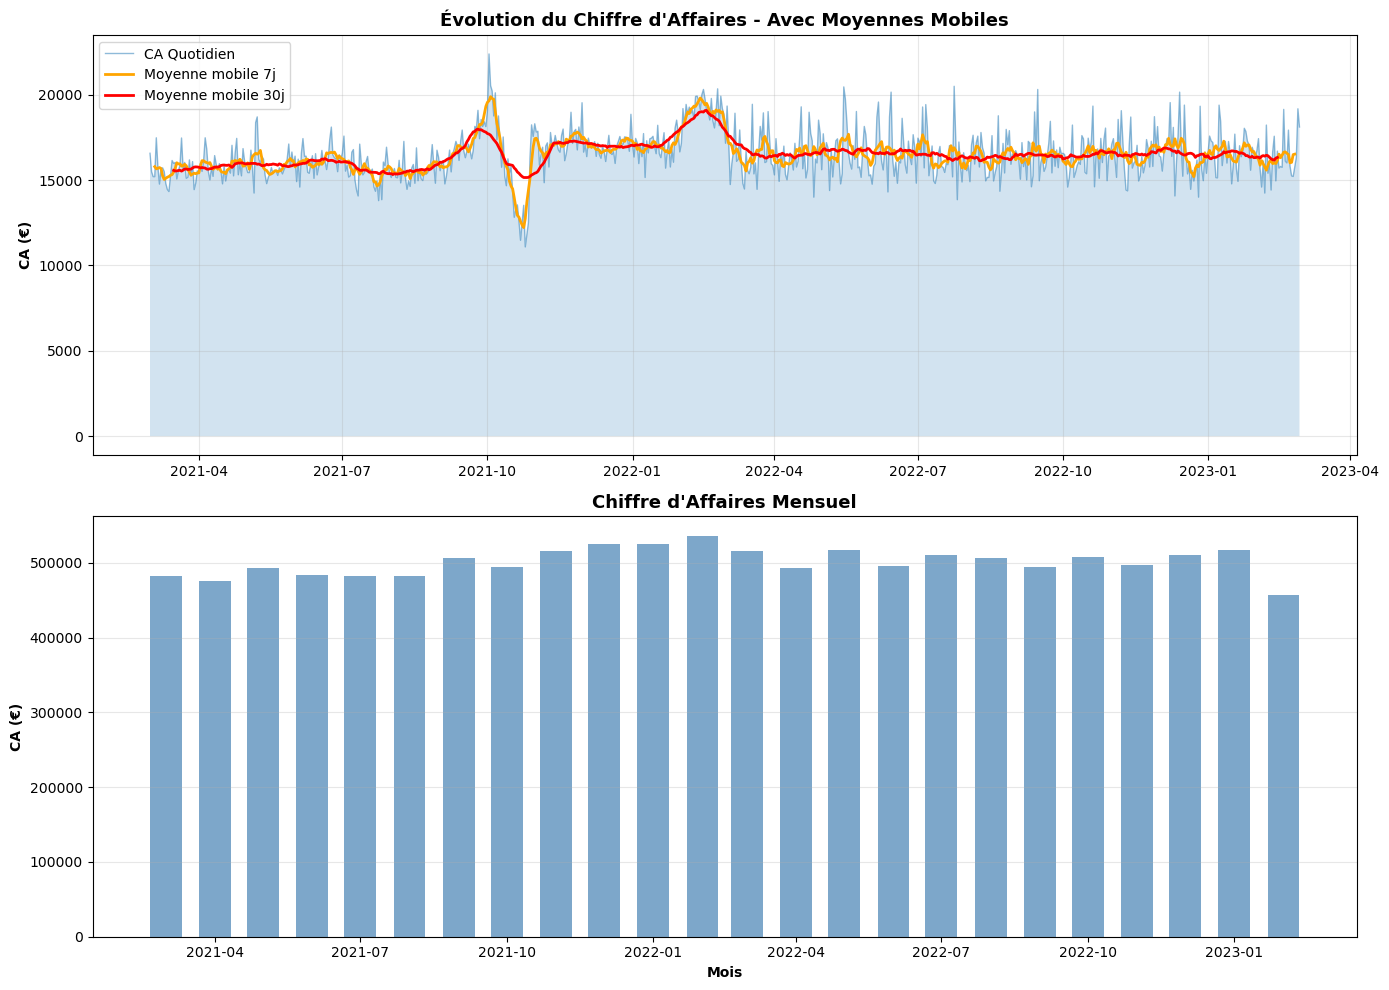


Interprétation:
- La courbe quotidienne montre la volatilité normale
- MA(7j) lisse les variations semaine par semaine
- MA(30j) montre la vraie tendance long terme


In [16]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Graphique 1: CA journalier + MA
ax1 = axes[0]
ax1.plot(data_daily['date'], data_daily['ca'], alpha=0.5, label='CA Quotidien', linewidth=1)
ax1.plot(data_daily['date'], data_daily['MA_7j'], label='Moyenne mobile 7j', linewidth=2, color='orange')
ax1.plot(data_daily['date'], data_daily['MA_30j'], label='Moyenne mobile 30j', linewidth=2, color='red')
ax1.fill_between(data_daily['date'], data_daily['ca'], alpha=0.2)
ax1.set_title('Évolution du Chiffre d\'Affaires - Avec Moyennes Mobiles', fontsize=13, fontweight='bold')
ax1.set_ylabel('CA (€)', fontweight='bold')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# Graphique 2: CA mensuel (bar chart)
ca_monthly = data.groupby(data['date'].dt.to_period('M'))['montant'].sum()
ax2 = axes[1]
ca_monthly.index = ca_monthly.index.to_timestamp()
ax2.bar(ca_monthly.index, ca_monthly.values, color='steelblue', alpha=0.7, width=20)
ax2.set_title('Chiffre d\'Affaires Mensuel', fontsize=13, fontweight='bold')
ax2.set_ylabel('CA (€)', fontweight='bold')
ax2.set_xlabel('Mois', fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nInterprétation:")
print("- La courbe quotidienne montre la volatilité normale")
print("- MA(7j) lisse les variations semaine par semaine")
print("- MA(30j) montre la vraie tendance long terme")


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">3.2.3 Évolution des KPIs Opérationnels </h3>
</div>

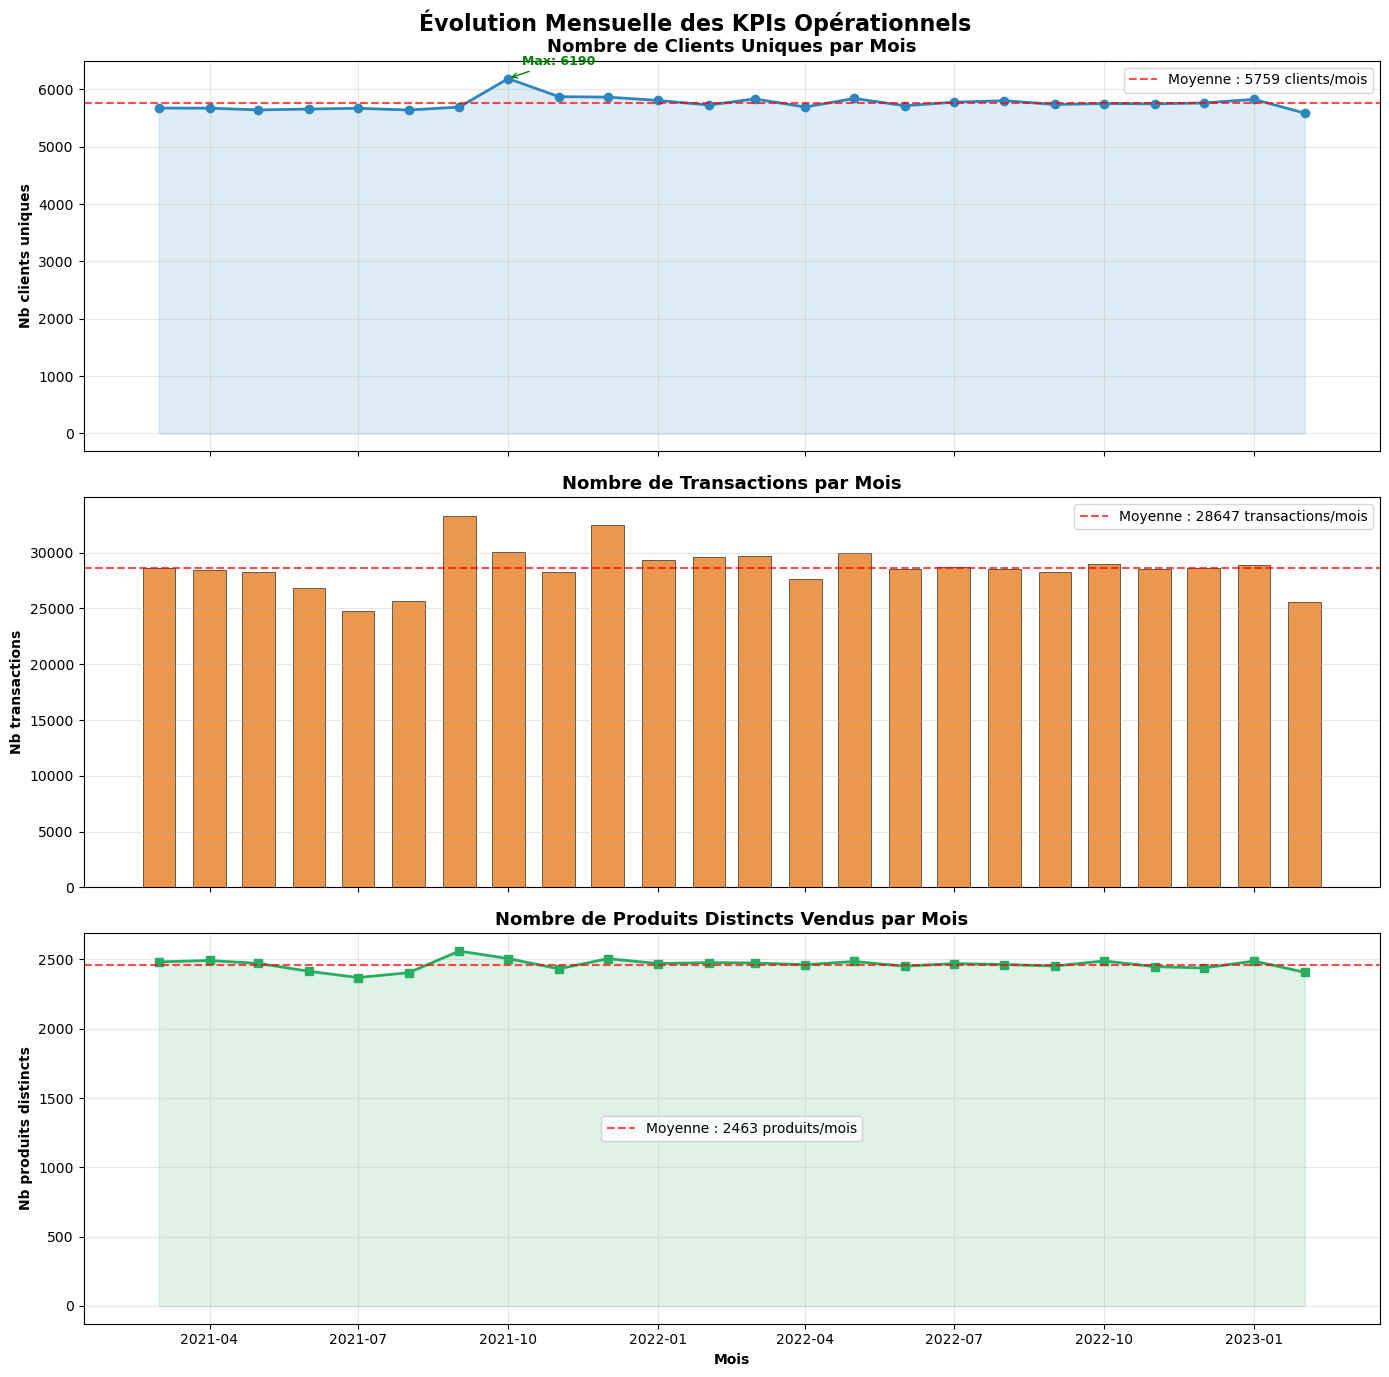


Récapitulatif mensuel :
            CA (€)  Transactions  Clients  Produits  Panier moyen (€)
date                                                                 
2021-03  482440.61         28601     5676      2482             16.87
2021-04  476109.30         28443     5674      2492             16.74
2021-05  492943.47         28285     5644      2471             17.43
2021-06  484088.56         26850     5659      2414             18.03
2021-07  482835.40         24738     5672      2369             19.52
2021-08  482284.79         25650     5642      2404             18.80
2021-09  507240.68         33314     5693      2560             15.23
2021-10  494733.16         30022     6190      2506             16.48
2021-11  516167.73         28311     5875      2432             18.23
2021-12  525917.28         32457     5867      2505             16.20
2022-01  525338.99         29343     5809      2470             17.90
2022-02  535571.50         29594     5729      2477             1

In [17]:
# --- Graphiques temporels des KPIs opérationnels ---
# (à ajouter JUSTE APRÈS le graphique CA + moyennes mobiles)
 
fig, axes = plt.subplots(3, 1, figsize=(14, 14), sharex=True)
fig.suptitle('Évolution Mensuelle des KPIs Opérationnels',
             fontsize=16, fontweight='bold', y=0.98)
 
mois_labels = ca_mensuel.index.to_timestamp()
 
# --- Graphique 1 : Nombre de clients uniques par mois ---
axes[0].plot(mois_labels, ca_mensuel['Clients_uniques'],
             marker='o', linewidth=2, color='#2E86C1', markersize=6)
axes[0].fill_between(mois_labels, ca_mensuel['Clients_uniques'],
                      alpha=0.15, color='#2E86C1')
mean_clients = ca_mensuel['Clients_uniques'].mean()
axes[0].axhline(mean_clients, color='red', linestyle='--', alpha=0.7,
                label=f'Moyenne : {mean_clients:.0f} clients/mois')
axes[0].set_ylabel('Nb clients uniques', fontweight='bold')
axes[0].set_title('Nombre de Clients Uniques par Mois', fontsize=13, fontweight='bold')
axes[0].legend(loc='best')
axes[0].grid(True, alpha=0.3)
# Annotation min/max
idx_max = ca_mensuel['Clients_uniques'].idxmax()
idx_min = ca_mensuel['Clients_uniques'].idxmin()
axes[0].annotate(f'Max: {ca_mensuel.loc[idx_max, "Clients_uniques"]}',
    xy=(idx_max.to_timestamp(), ca_mensuel.loc[idx_max, 'Clients_uniques']),
    fontsize=9, fontweight='bold', color='green',
    textcoords='offset points', xytext=(10, 10),
    arrowprops=dict(arrowstyle='->', color='green'))
 
# --- Graphique 2 : Nombre de transactions par mois ---
axes[1].bar(mois_labels, ca_mensuel['Transactions'],
            color='#E67E22', alpha=0.8, width=20, edgecolor='black', linewidth=0.5)
mean_trans = ca_mensuel['Transactions'].mean()
axes[1].axhline(mean_trans, color='red', linestyle='--', alpha=0.7,
                label=f'Moyenne : {mean_trans:.0f} transactions/mois')
axes[1].set_ylabel('Nb transactions', fontweight='bold')
axes[1].set_title('Nombre de Transactions par Mois', fontsize=13, fontweight='bold')
axes[1].legend(loc='best')
axes[1].grid(True, alpha=0.3, axis='y')
 
# --- Graphique 3 : Nombre de produits distincts vendus par mois ---
axes[2].plot(mois_labels, ca_mensuel['Produits_vendus'],
             marker='s', linewidth=2, color='#27AE60', markersize=6)
axes[2].fill_between(mois_labels, ca_mensuel['Produits_vendus'],
                      alpha=0.15, color='#27AE60')
mean_prod = ca_mensuel['Produits_vendus'].mean()
axes[2].axhline(mean_prod, color='red', linestyle='--', alpha=0.7,
                label=f'Moyenne : {mean_prod:.0f} produits/mois')
axes[2].set_ylabel('Nb produits distincts', fontweight='bold')
axes[2].set_title('Nombre de Produits Distincts Vendus par Mois', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Mois', fontweight='bold')
axes[2].legend(loc='best')
axes[2].grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig('kpis_temporels.png', dpi=150, bbox_inches='tight')
plt.show()
 
# --- Tableau récapitulatif mensuel ---
print('\nRécapitulatif mensuel :')
recap = ca_mensuel[['CA', 'Transactions', 'Clients_uniques', 'Produits_vendus', 'Montant_moyen']].copy()
recap.columns = ['CA (\u20ac)', 'Transactions', 'Clients', 'Produits', 'Panier moyen (\u20ac)']
print(recap.round(2).to_string())
print(f'\nMoyennes mensuelles :')
print(f'  Clients : {mean_clients:.0f} | Transactions : {mean_trans:.0f} | Produits : {mean_prod:.0f}')

print("\nInterprétation:")
print("- Les KPIs opérationnels sont relativement stables sur la période")
print("- Légère baisse saisonnière visible en fin d'année")
print("- La base clients active reste constante (~5 750 clients/mois)")

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">3.3 Chiffre d'Affaires par Catégorie </h3>
</div>

                           CA  Nombre_transactions  Montant_moyen  Pourcentage
categorie_nom                                                                 
Cat. 1 - Romans    4827657.11               235592      20.491600        40.14
Cat. 0 - Essais    4419730.97               415459      10.638188        36.75
Cat. 2 - Jeunesse  2780275.02                36483      76.207412        23.12

Interprétation:
- Catégorie dominante: Cat. 1 - Romans (4,827,657 €)
- Les 3 catégories ont des profils de vente distincts (CA, volume, panier moyen)


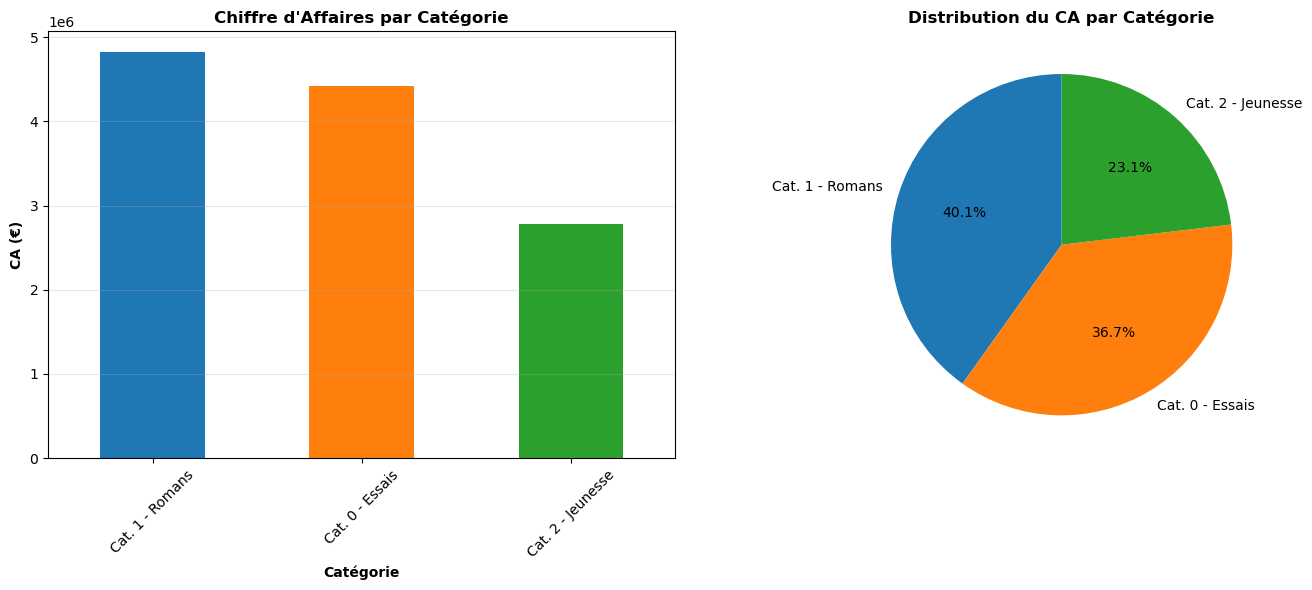

In [18]:
# CA par catégorie
# Rappel mapping : categ 0 = Essais, 1 = Romans, 2 = Jeunesse
ca_categ = data.groupby('categorie_nom')['montant'].agg(['sum', 'count', 'mean'])
ca_categ.columns = ['CA', 'Nombre_transactions', 'Montant_moyen']
ca_categ['Pourcentage'] = (ca_categ['CA'] / ca_categ['CA'].sum() * 100).round(2)
ca_categ = ca_categ.sort_values('CA', ascending=False)

print(ca_categ)
print("\nInterprétation:")
print(f"- Catégorie dominante: {ca_categ.index[ca_categ['CA'].argmax()]} ({ca_categ['CA'].max():,.0f} €)")
print("- Les 3 catégories ont des profils de vente distincts (CA, volume, panier moyen)")
# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 6))


# Bar chart
ax1 = axes[0]
ca_categ['CA'].plot(kind='bar', ax=ax1, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax1.set_title('Chiffre d\'Affaires par Catégorie', fontweight='bold', fontsize=12)
ax1.set_ylabel('CA (€)', fontweight='bold')
ax1.set_xlabel('Catégorie', fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)

# Pie chart
ax2 = axes[1]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
ax2.pie(ca_categ['CA'], labels=ca_categ.index, autopct='%1.1f%%', colors=colors, startangle=90)
ax2.set_title('Distribution du CA par Catégorie', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">3.4 Top 10 et Flop 10 des produits </h3>
</div>

TOP 10 PRODUITS (par CA)
id_prod       CA  Nb_ventes  Montant_moyen  Price         Categorie
  2_159 94893.50        650         145.99 145.99 Cat. 2 - Jeunesse
  2_135 69334.95       1005          68.99  68.99 Cat. 2 - Jeunesse
  2_112 65407.76        968          67.57  67.57 Cat. 2 - Jeunesse
  2_102 60736.78       1027          59.14  59.14 Cat. 2 - Jeunesse
  2_209 56971.86        814          69.99  69.99 Cat. 2 - Jeunesse
  1_395 56617.47       1953          28.99  28.99   Cat. 1 - Romans
  1_369 56136.60       2340          23.99  23.99   Cat. 1 - Romans
  2_110 53846.25        865          62.25  62.25 Cat. 2 - Jeunesse
  1_383 53834.43       1857          28.99  28.99   Cat. 1 - Romans
  1_414 53522.18       2246          23.83  23.83   Cat. 1 - Romans

FLOP 10 PRODUITS (par CA)
id_prod   CA  Nb_ventes  Montant_moyen  Price       Categorie
 0_1840 2.56          2           1.28   1.28 Cat. 0 - Essais
  0_898 2.54          2           1.27   1.27 Cat. 0 - Essais
 0_1498 2.48  

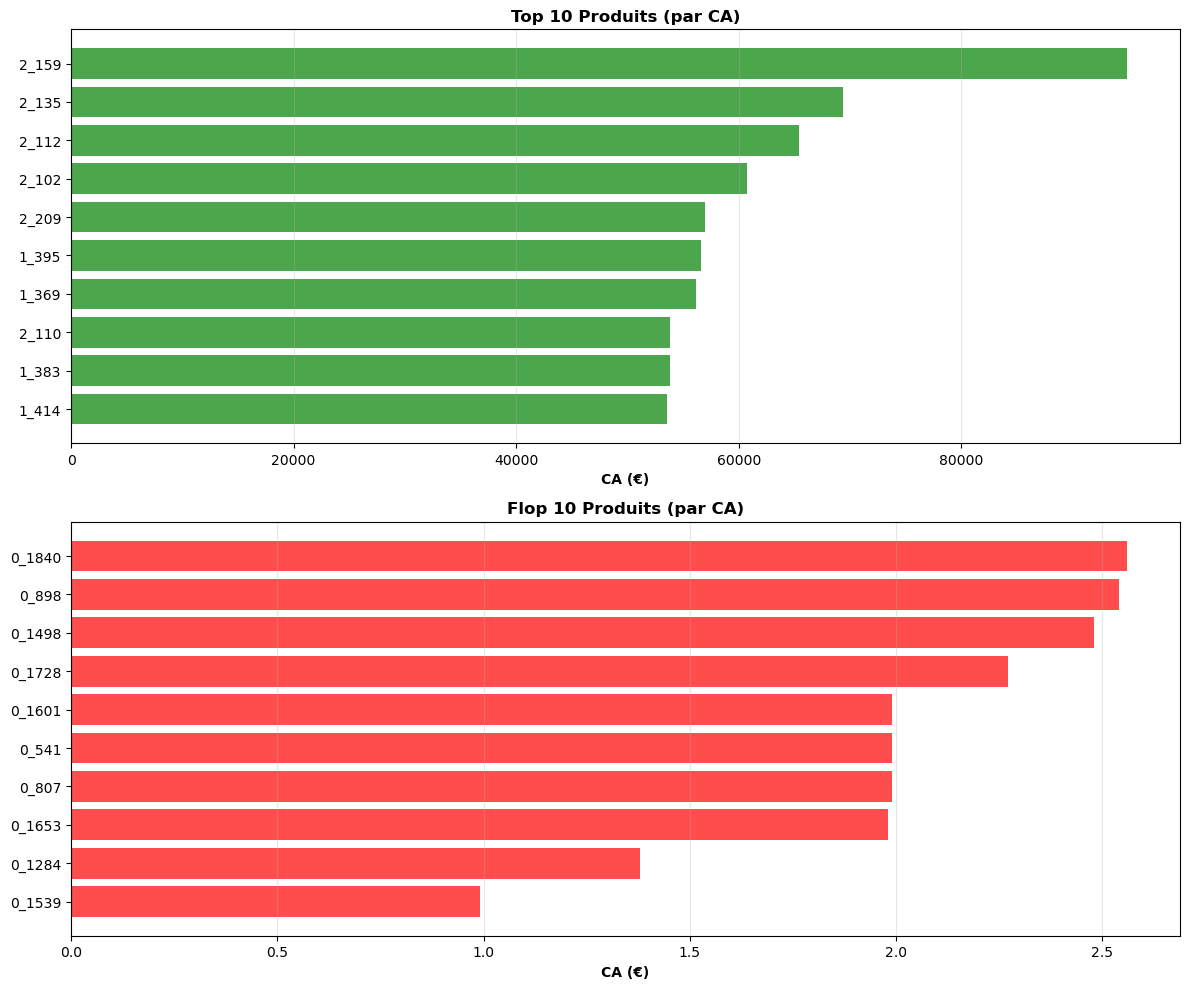

In [19]:
# Analyse Pareto (règle 80/20) montre que les 20% des des produits générent 80% du CA.
# Identification de ces produits est crucial pour la stratégie d'inventaire.
# CA par produit
ca_produit = data.groupby('id_prod').agg({
    'montant': ['sum', 'count', 'mean'],
    'price': 'first',
    'categorie_nom': 'first'
}).reset_index()

ca_produit.columns = ['id_prod', 'CA', 'Nb_ventes', 'Montant_moyen', 'Price', 'Categorie']
ca_produit = ca_produit.sort_values('CA', ascending=False)

# TOP 10
top10 = ca_produit.head(10)
print("=" * 80)
print("TOP 10 PRODUITS (par CA)")
print("=" * 80)
print(top10.to_string(index=False))

# FLOP 10
flop10 = ca_produit.tail(10)
print("\n" + "=" * 80)
print("FLOP 10 PRODUITS (par CA)")
print("=" * 80)
print(flop10.to_string(index=False))
print("\nInterprétation:")
print("- Écart considérable entre top et flop produits")
print("- Les top produits sont les piliers du CA, les flop indiquent un possible 'long tail'")
# Visualisation TOP 10
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

ax1 = axes[0]
top10_plot = top10.sort_values('CA')
ax1.barh(top10_plot['id_prod'].astype(str), top10_plot['CA'], color='green', alpha=0.7)
ax1.set_title('Top 10 Produits (par CA)', fontweight='bold', fontsize=12)
ax1.set_xlabel('CA (€)', fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')

ax2 = axes[1]
flop10_plot = flop10.sort_values('CA')
ax2.barh(flop10_plot['id_prod'].astype(str), flop10_plot['CA'], color='red', alpha=0.7)
ax2.set_title('Flop 10 Produits (par CA)', fontweight='bold', fontsize=12)
ax2.set_xlabel('CA (€)', fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">3.4.1 Analyse Pareto (Courbe 80/20) </h3>
</div>

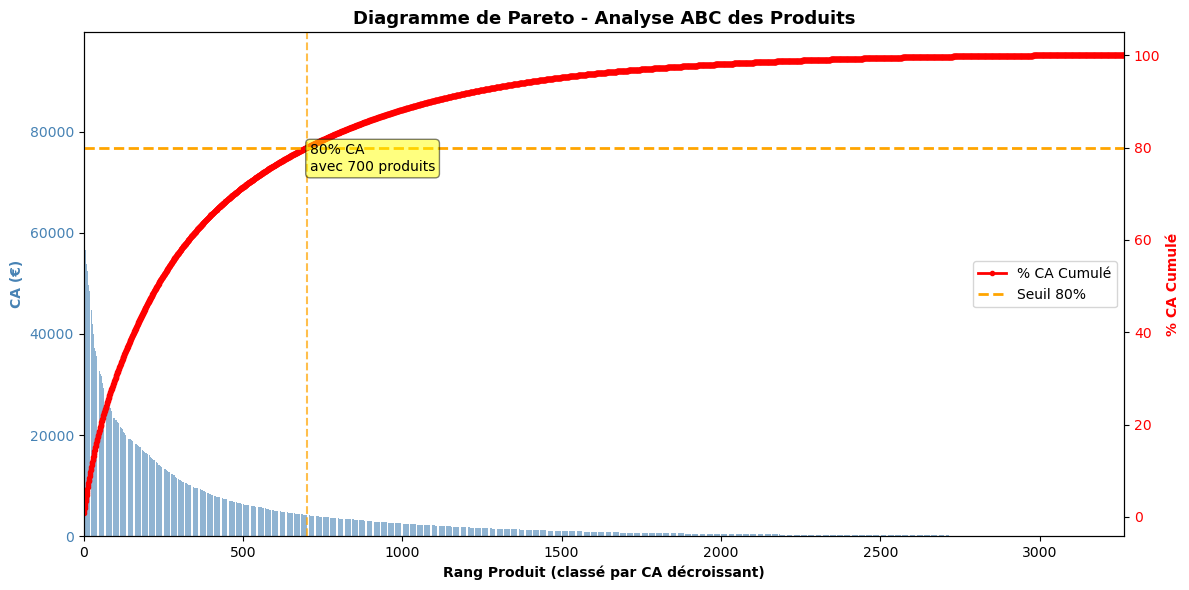


80% du CA provient de 700 produits sur 3265 = 21.4%

Interprétation:
- La règle de Pareto se confirme : une minorité de produits génère l'essentiel du CA
- Stratégie recommandée : protéger le stock et la visibilité des top produits


In [20]:
# Préparer données pour Pareto
pareto_data = ca_produit.sort_values('CA', ascending=False).reset_index(drop=True)
pareto_data['CA_cumul'] = pareto_data['CA'].cumsum()
pareto_data['CA_cumul_pct'] = (pareto_data['CA_cumul'] / pareto_data['CA'].sum() * 100)
pareto_data['produit_rank'] = range(1, len(pareto_data) + 1)
pareto_data['produit_pct'] = (pareto_data['produit_rank'] / len(pareto_data) * 100)

# Créer graphique Pareto
fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar chart (CA par produit)
ax1.bar(pareto_data['produit_rank'], pareto_data['CA'], alpha=0.6, color='steelblue', label='CA par produit')
ax1.set_xlim(0, len(pareto_data))
ax1.set_xlabel('Rang Produit (classé par CA décroissant)', fontweight='bold')
ax1.set_ylabel('CA (€)', fontweight='bold', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_title('Diagramme de Pareto - Analyse ABC des Produits', fontweight='bold', fontsize=13)

# Courbe cumulative (sur axe secondaire)
ax2 = ax1.twinx()
ax2.plot(pareto_data['produit_rank'], pareto_data['CA_cumul_pct'], color='red', marker='o', 
         linewidth=2, markersize=3, label='% CA Cumulé')
ax2.axhline(y=80, color='orange', linestyle='--', linewidth=2, label='Seuil 80%')
ax2.set_ylabel('% CA Cumulé', fontweight='bold', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Identifier le point 80%
idx_80 = pareto_data[pareto_data['CA_cumul_pct'] >= 80].iloc[0]
ax2.axvline(x=idx_80['produit_rank'], color='orange', linestyle='--', alpha=0.7)
ax2.text(idx_80['produit_rank'] + 10, 75, f"80% CA\navec {int(idx_80['produit_rank'])} produits", 
         fontsize=10, bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

plt.legend(loc='center right')
plt.tight_layout()
plt.show()

print(f"\n80% du CA provient de {int(idx_80['produit_rank'])} produits sur {len(pareto_data)} = {idx_80['produit_pct']:.1f}%")
print("\nInterprétation:")
print("- La règle de Pareto se confirme : une minorité de produits génère l'essentiel du CA")
print("- Stratégie recommandée : protéger le stock et la visibilité des top produits")

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">3.4.2 Profil détaillé des clients BtoB et répartition de leur CA</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">3.4.2.1 Identification et tableau récapitulatif des BtoB</h3>
</div>

In [21]:
# --- Identification des 4 clients BtoB (top CA) ---
ca_par_client = data.groupby('client_id').agg(
    ca_total=('price', 'sum'),
    nb_transactions=('session_id', 'nunique'),
    nb_articles=('id_prod', 'count'),
    nb_categories=('categ', 'nunique'),
    premiere_date=('date', 'min'),
    derniere_date=('date', 'max')
).reset_index()
 
ca_par_client = ca_par_client.sort_values('ca_total', ascending=False)
 
# Les 4 premiers sont les BtoB
btob = ca_par_client.head(4).copy()
btob['panier_moyen'] = (btob['ca_total'] / btob['nb_transactions']).round(2)
btob['articles_par_session'] = (btob['nb_articles'] / btob['nb_transactions']).round(1)
 
print('=' * 70)
print('PROFIL DES 4 CLIENTS BtoB')
print('=' * 70)
print(btob[['client_id', 'ca_total', 'nb_transactions', 'nb_articles',
            'nb_categories', 'panier_moyen', 'articles_par_session']].to_string(index=False))
 
# Poids dans le CA total
ca_total_global = data['price'].sum()
ca_btob = btob['ca_total'].sum()
print(f'\nCA total global : {ca_total_global:,.2f} \u20ac')
print(f'CA des 4 BtoB   : {ca_btob:,.2f} \u20ac ({ca_btob/ca_total_global*100:.1f}%)')
print(f'CA BtoC restant : {ca_total_global - ca_btob:,.2f} \u20ac ({(1-ca_btob/ca_total_global)*100:.1f}%)')


PROFIL DES 4 CLIENTS BtoB
client_id  ca_total  nb_transactions  nb_articles  nb_categories  panier_moyen  articles_par_session
   c_1609 326039.89            10997        25586              3         29.65                   2.3
   c_4958 290227.03             3851         5222              3         75.36                   1.4
   c_6714 153918.60             2620         9199              3         58.75                   3.5
   c_3454 114110.57             5571         6793              3         20.48                   1.2

CA total global : 12,027,663.10 €
CA des 4 BtoB   : 884,296.09 € (7.4%)
CA BtoC restant : 11,143,367.01 € (92.6%)


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">3.4.2.2 Quelles catégories achètent les BtoB? </h3>
</div>

In [22]:
# --- Répartition du CA BtoB par catégorie ---
# Objectif : analyser si les clients BtoB achètent les mêmes catégories
# que l'ensemble des clients, ou s'ils sont concentrés sur certains segments.
# Cela permet d'identifier les leviers de négociation et le risque de dépendance.
btob_ids = btob['client_id'].tolist()
data_btob = data[data['client_id'].isin(btob_ids)] # Filtrer les transactions BtoB
 
ca_btob_categ = data_btob.groupby('categ')['price'].sum().reset_index()
ca_btob_categ.columns = ['Catégorie', 'CA BtoB']
ca_btob_categ['% du CA BtoB'] = (ca_btob_categ['CA BtoB'] / ca_btob_categ['CA BtoB'].sum() * 100).round(1)
 
# Comparaison avec le CA global pour voir les écarts de structure
ca_global_categ = data.groupby('categ')['price'].sum().reset_index()
ca_global_categ.columns = ['Catégorie', 'CA Global']
ca_global_categ['% du CA Global'] = (ca_global_categ['CA Global'] / ca_global_categ['CA Global'].sum() * 100).round(1)
 
comparaison = ca_btob_categ.merge(ca_global_categ, on='Catégorie')
comparaison['Catégorie'] = ['Cat. 0', 'Cat. 1', 'Cat. 2']
print('\nComparaison répartition CA par catégorie :')
print(comparaison.to_string(index=False))



Comparaison répartition CA par catégorie :
Catégorie   CA BtoB  % du CA BtoB  CA Global  % du CA Global
   Cat. 0 300530.28          34.0 4419730.97            36.7
   Cat. 1 307555.25          34.8 4827657.11            40.1
   Cat. 2 276210.56          31.2 2780275.02            23.1


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">3.4.2.3 Evolution temporelle des achats BtoB </h3>
</div>

In [23]:
# --- Évolution mensuelle du CA BtoB vs CA global ---
# Objectif : suivre le poids du CA BtoB dans le temps pour détecter
# une saisonnalité ou une tendance de croissance/décroissance des achats BtoB.
# Utile pour anticiper les variations de trésorerie liées à ces gros clients.

data_btob['mois'] = data_btob['date'].dt.to_period('M')
ca_btob_mois = data_btob.groupby('mois')['price'].sum().reset_index()
ca_btob_mois.columns = ['mois', 'ca_btob']
 
# CA global par mois pour calculer le ratio BtoB/total
data['mois'] = data['date'].dt.to_period('M')
ca_global_mois = data.groupby('mois')['price'].sum().reset_index()
ca_global_mois.columns = ['mois', 'ca_global']
 
ca_compare_mois = ca_global_mois.merge(ca_btob_mois, on='mois', how='left').fillna(0)
ca_compare_mois['pct_btob'] = (ca_compare_mois['ca_btob'] / ca_compare_mois['ca_global'] * 100).round(1)
ca_compare_mois['ca_btoc'] = ca_compare_mois['ca_global'] - ca_compare_mois['ca_btob']
 
print('\nPoids du CA BtoB par mois :')
print(ca_compare_mois[['mois', 'ca_global', 'ca_btob', 'pct_btob']].to_string(index=False))



Poids du CA BtoB par mois :
   mois  ca_global  ca_btob  pct_btob
2021-03  482440.61 36521.90       7.6
2021-04  476109.30 36771.45       7.7
2021-05  492943.47 38056.01       7.7
2021-06  484088.56 36986.39       7.6
2021-07  482835.40 35242.25       7.3
2021-08  482284.79 36282.49       7.5
2021-09  507240.68 36318.88       7.2
2021-10  494733.16 27335.94       5.5
2021-11  516167.73 38075.65       7.4
2021-12  525917.28 38193.88       7.3
2022-01  525338.99 36528.91       7.0
2022-02  535571.50 42644.37       8.0
2022-03  515456.53 38507.69       7.5
2022-04  492998.94 35682.88       7.2
2022-05  517132.60 37932.60       7.3
2022-06  496016.12 38705.34       7.8
2022-07  510783.12 37318.17       7.3
2022-08  506467.27 36835.13       7.3
2022-09  494114.53 34998.80       7.1
2022-10  507917.77 37102.28       7.3
2022-11  496664.94 37277.02       7.5
2022-12  510219.50 39727.69       7.8
2023-01  517540.55 36056.05       7.0
2023-02  456679.76 35194.32       7.7


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">3.4.2.4 Visualisation: 4 graphiques </h3>
</div>

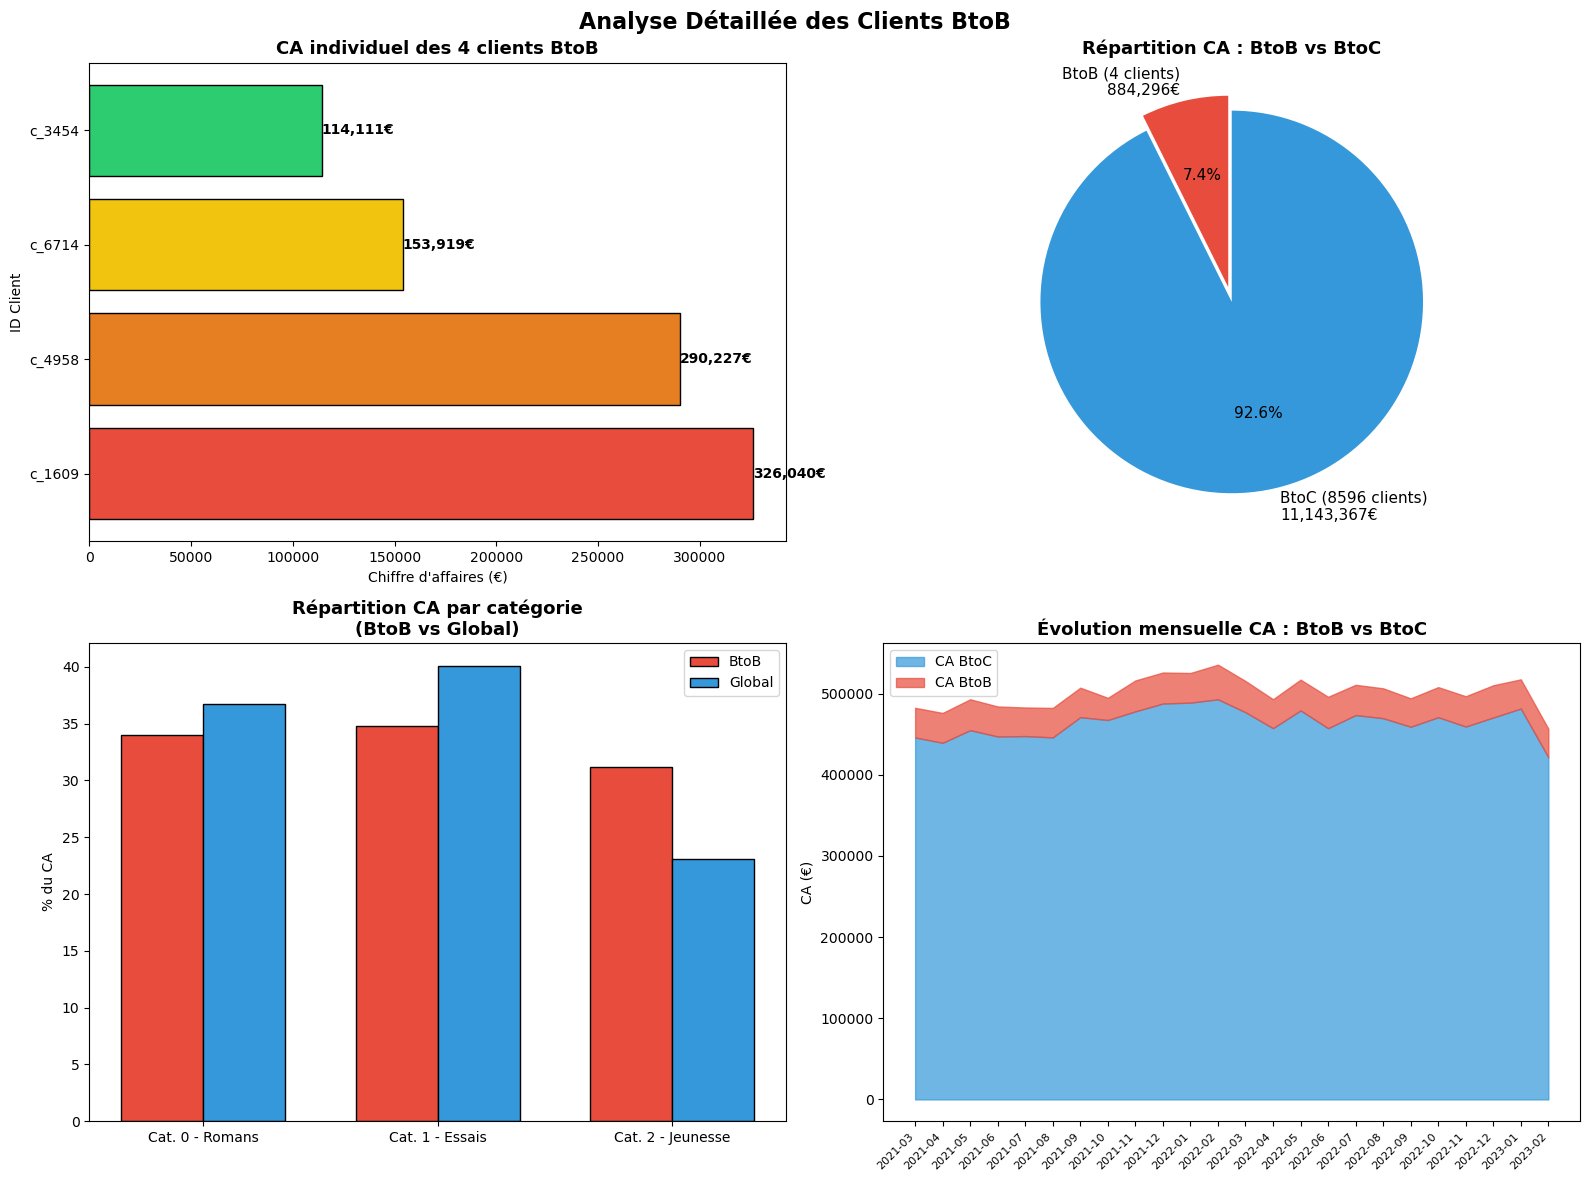


Interprétation:
- c_1609 est le plus gros client BtoB (326,040 €)
- Les 4 BtoB représentent 7.4% du CA total (884,296 €)
- Leur répartition par catégorie suit globalement la tendance globale
- L'évolution mensuelle montre une contribution BtoB stable dans le temps


In [24]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Analyse Détaillée des Clients BtoB', fontsize=16, fontweight='bold', y=0.98)
 
# --- Graphique 1 : CA individuel des 4 BtoB ---
colors_btob = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71']
bars = axes[0,0].barh(btob['client_id'].astype(str), btob['ca_total'],
                       color=colors_btob, edgecolor='black')
for bar, val in zip(bars, btob['ca_total']):
    axes[0,0].text(val + 100, bar.get_y() + bar.get_height()/2,
                   f'{val:,.0f}\u20ac', va='center', fontweight='bold')
axes[0,0].set_title('CA individuel des 4 clients BtoB', fontsize=13, fontweight='bold')
axes[0,0].set_xlabel('Chiffre d\'affaires (\u20ac)')
axes[0,0].set_ylabel('ID Client')
 
# --- Graphique 2 : Pie BtoB vs BtoC ---
ca_btoc = ca_total_global - ca_btob
axes[0,1].pie([ca_btob, ca_btoc],
              labels=[f'BtoB (4 clients)\n{ca_btob:,.0f}\u20ac',
                      f'BtoC ({len(ca_par_client)-4} clients)\n{ca_btoc:,.0f}\u20ac'],
              autopct='%1.1f%%', colors=['#e74c3c', '#3498db'],
              explode=[0.08, 0], startangle=90,
              textprops={'fontsize': 11})
axes[0,1].set_title('Répartition CA : BtoB vs BtoC', fontsize=13, fontweight='bold')
 
# --- Graphique 3 : Répartition par catégorie (BtoB vs Global) ---
x = range(len(ca_btob_categ))
w = 0.35
axes[1,0].bar([i - w/2 for i in x], comparaison['% du CA BtoB'],
              w, label='BtoB', color='#e74c3c', edgecolor='black')
axes[1,0].bar([i + w/2 for i in x], comparaison['% du CA Global'],
              w, label='Global', color='#3498db', edgecolor='black')
axes[1,0].set_xticks(list(x))
axes[1,0].set_xticklabels(['Cat. 0 - Romans', 'Cat. 1 - Essais', 'Cat. 2 - Jeunesse'])
axes[1,0].set_ylabel('% du CA')
axes[1,0].set_title('Répartition CA par catégorie\n(BtoB vs Global)', fontsize=13, fontweight='bold')
axes[1,0].legend()
 
# --- Graphique 4 : Évolution % BtoB dans le CA mensuel ---
mois_str = ca_compare_mois['mois'].astype(str)
axes[1,1].fill_between(range(len(mois_str)), ca_compare_mois['ca_btoc'],
                        label='CA BtoC', alpha=0.7, color='#3498db')
axes[1,1].fill_between(range(len(mois_str)), ca_compare_mois['ca_btoc'],
                        ca_compare_mois['ca_global'],
                        label='CA BtoB', alpha=0.7, color='#e74c3c')
axes[1,1].set_xticks(range(len(mois_str)))
axes[1,1].set_xticklabels(mois_str, rotation=45, ha='right', fontsize=8)
axes[1,1].set_ylabel('CA (\u20ac)')
axes[1,1].set_title('Évolution mensuelle CA : BtoB vs BtoC', fontsize=13, fontweight='bold')
axes[1,1].legend()
 
plt.tight_layout()
plt.savefig('profil_btob_complet.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nInterprétation:")
print(f"- c_1609 est le plus gros client BtoB ({btob.iloc[0]['ca_total']:,.0f} €)")
print(f"- Les 4 BtoB représentent {ca_btob/ca_total_global*100:.1f}% du CA total ({ca_btob:,.0f} €)")
print("- Leur répartition par catégorie suit globalement la tendance globale")
print("- L'évolution mensuelle montre une contribution BtoB stable dans le temps")


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">3.5 Courbe de Lorenz et Coefficient de Gini </h3>
</div>

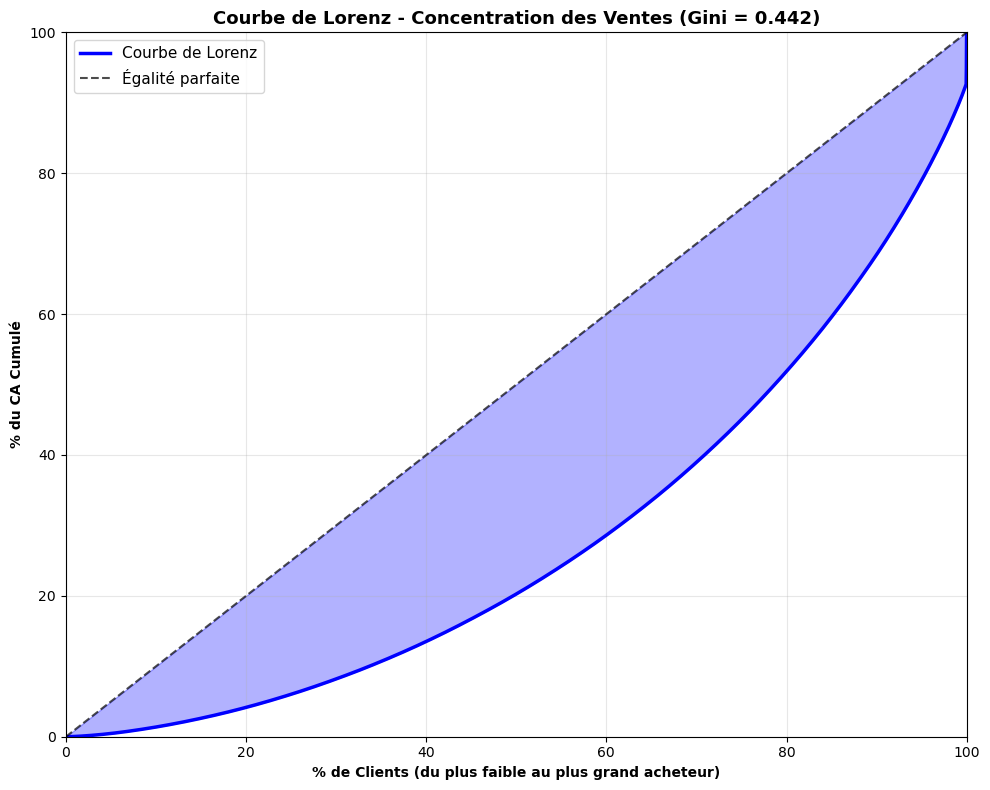

Coefficient de Gini: 0.4419

Interprétation:
- Gini = 0.4419 : Distribution relativement égale
- Les top clients représentent une part importante du CA
- À adapter: stratégie de fidélisation vs. acquisition
════════════════════════════════════════════════════════════════════════
     CONCLUSION SUR CERTAINS CLIENTS. LECTURE DE LA COURBE DE LORENZ    
════════════════════════════════════════════════════════════════════════

  OBSERVATION ...... La courbe présente un décrochement quasi-vertical
                     sur les derniers pourcents en abscisse.

  IDENTIFICATION ... Ce coude correspond aux 4 clients BtoB :
                     ~0,05 % des clients captent ≈ 7 % du CA total.

  CONCLUSION ....... Ces 4 clients constituent une population atypique
                     aux volumes d'achat hors-norme (×140 vs moyenne).
                     Ils expliquent l'essentiel du Gini (0,442).

  CONSÉQUENCES ..... • Fidélisation critique (exposition concentrée).
                     • Exclusio

In [25]:
# La courbe de Lorenz et le coefficient de Gini mesurent la concentration des ventes parmi les clients. 
# Un Gini de 0 = distribution parfaitement égale, 1 = concentration extrême.
# Calculer CA par client
ca_client = data.groupby('client_id')['montant'].sum().reset_index()
ca_client.columns = ['client_id', 'ca']
ca_client = ca_client.sort_values('ca').reset_index(drop=True)

# Courbe de Lorenz
ca_client['ca_cumul'] = ca_client['ca'].cumsum()
ca_client['ca_cumul_pct'] = (ca_client['ca_cumul'] / ca_client['ca'].sum() * 100)
ca_client['client_idx'] = range(len(ca_client))
ca_client['client_pct'] = (ca_client['client_idx'] / len(ca_client) * 100)

# Coefficient de Gini
def compute_gini(values):
    sorted_vals = np.sort(values)
    n = len(values)
    index = np.arange(1, n + 1)
    gini = (2 * np.sum(index * sorted_vals)) / (n * np.sum(sorted_vals)) - (n + 1) / n
    return gini

gini = compute_gini(ca_client['ca'].values)

# Visualisation
fig, ax = plt.subplots(figsize=(10, 8))

# Courbe de Lorenz
ax.plot(ca_client['client_pct'], ca_client['ca_cumul_pct'], 'b-', linewidth=2.5, label='Courbe de Lorenz')

# Ligne d'égalité parfaite (45°)
ax.plot([0, 100], [0, 100], 'k--', linewidth=1.5, label='Égalité parfaite', alpha=0.7)

# Remplir zone de concentration
ax.fill_between(ca_client['client_pct'], ca_client['ca_cumul_pct'], 
                ca_client['client_pct'], alpha=0.3, color='blue')

ax.set_xlabel('% de Clients (du plus faible au plus grand acheteur)', fontweight='bold')
ax.set_ylabel('% du CA Cumulé', fontweight='bold')
ax.set_title(f'Courbe de Lorenz - Concentration des Ventes (Gini = {gini:.3f})', 
             fontweight='bold', fontsize=13)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left', fontsize=11)
ax.set_xlim([0, 100])
ax.set_ylim([0, 100])

plt.tight_layout()
plt.show()

print(f"Coefficient de Gini: {gini:.4f}")
print("\nInterprétation:")
print(f"- Gini = {gini:.4f} : Distribution {'concentrée' if gini > 0.5 else 'relativement égale'}")
print("- Les top clients représentent une part importante du CA")
print("- À adapter: stratégie de fidélisation vs. acquisition")
print("═" * 72)
print(" CONCLUSION SUR CERTAINS CLIENTS. LECTURE DE LA COURBE DE LORENZ".center(72))
print("═" * 72)
print()
print("  OBSERVATION ...... La courbe présente un décrochement quasi-vertical")
print("                     sur les derniers pourcents en abscisse.")
print()
print("  IDENTIFICATION ... Ce coude correspond aux 4 clients BtoB :")
print("                     ~0,05 % des clients captent ≈ 7 % du CA total.")
print()
print("  CONCLUSION ....... Ces 4 clients constituent une population atypique")
print("                     aux volumes d'achat hors-norme (×140 vs moyenne).")
print("                     Ils expliquent l'essentiel du Gini (0,442).")
print()
print("  CONSÉQUENCES ..... • Fidélisation critique (exposition concentrée).")
print("                     • Exclusion justifiée du notebook de corrélations")
print("                       (outliers statistiques).")
print("                     • Base BtoC équilibrée : potentiel d'up-sell.")
print("═" * 72)


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">3.5.1 Analyse Pareto Clients </h3>
</div>

Top 1% (86 clients) = 10.5% du CA
Top 5% (430 clients) = 21.0% du CA
Top 10% (860 clients) = 31.6% du CA
Top 20% (1720 clients) = 48.1% du CA
Top 50% (4300 clients) = 79.7% du CA


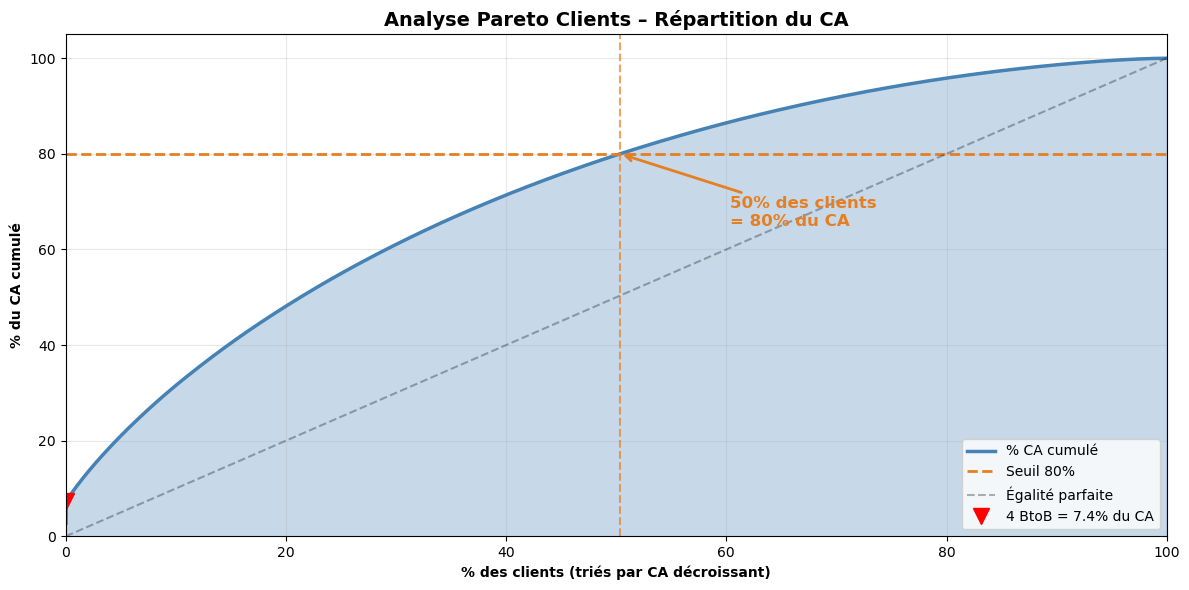


Interprétation:
- 50% des clients génèrent 80% du CA
- La concentration clients est modérée (cohérent avec le Gini de 0.44)
- Les 4 BtoB sont marqués en rouge : faible % de clients mais impact significatif


In [26]:
# === 3.5.1 Analyse Pareto Clients (règle 80/20) ===
# Complément de la courbe de Lorenz : identifie le % de clients
# nécessaire pour atteindre 80% du CA.

# CA par client (trié décroissant)
ca_par_client = data.groupby('client_id')['montant'].sum()
ca_par_client = ca_par_client.sort_values(ascending=False).reset_index()
ca_par_client.columns = ['client_id', 'ca']

# Calcul cumulatif
ca_total = ca_par_client['ca'].sum()
ca_par_client['ca_cumul'] = ca_par_client['ca'].cumsum()
ca_par_client['ca_cumul_pct'] = ca_par_client['ca_cumul'] / ca_total * 100
ca_par_client['client_rank'] = range(1, len(ca_par_client) + 1)
ca_par_client['client_pct'] = ca_par_client['client_rank'] / len(ca_par_client) * 100

# Point 80%
seuil_80 = ca_par_client[ca_par_client['ca_cumul_pct'] >= 80].iloc[0]

# Déciles
n = len(ca_par_client)
for pct in [1, 5, 10, 20, 50]:
    nb = int(n * pct / 100)
    ca_pct = ca_par_client.head(nb)['ca'].sum() / ca_total * 100
    print(f'Top {pct}% ({nb} clients) = {ca_pct:.1f}% du CA')

# --- Graphique Pareto Clients ---
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.fill_between(ca_par_client['client_pct'],
                 ca_par_client['ca_cumul_pct'],
                 alpha=0.3, color='steelblue')
ax1.plot(ca_par_client['client_pct'],
         ca_par_client['ca_cumul_pct'],
         color='steelblue', linewidth=2.5, label='% CA cumulé')

# Ligne 80%
ax1.axhline(y=80, color='#E67E22', linestyle='--', linewidth=2, label='Seuil 80%')
ax1.axvline(x=seuil_80['client_pct'], color='#E67E22',
            linestyle='--', alpha=0.7)
# Diagonale (distribution égale)
ax1.plot([0, 100], [0, 100], 'k--', alpha=0.3, label='Égalité parfaite')

# Annotation
ax1.annotate(f'{seuil_80["client_pct"]:.0f}% des clients\n= 80% du CA',
    xy=(seuil_80['client_pct'], 80),
    xytext=(seuil_80['client_pct'] + 10, 65),
    fontsize=12, fontweight='bold', color='#E67E22',
    arrowprops=dict(arrowstyle='->', color='#E67E22', lw=2))

# Marquer les 4 BtoB
btob_pct = 4 / n * 100
btob_ca_pct = ca_par_client.head(4)['ca'].sum() / ca_total * 100
ax1.plot(btob_pct, btob_ca_pct, 'rv', markersize=12,
         label=f'4 BtoB = {btob_ca_pct:.1f}% du CA')

ax1.set_xlabel('% des clients (triés par CA décroissant)', fontweight='bold')
ax1.set_ylabel('% du CA cumulé', fontweight='bold')
ax1.set_title('Analyse Pareto Clients \u2013 Répartition du CA',
              fontsize=14, fontweight='bold')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 100)
ax1.set_ylim(0, 105)
plt.tight_layout()
plt.show()

print("\nInterprétation:")
print(f"- {seuil_80['client_pct']:.0f}% des clients génèrent 80% du CA")
print("- La concentration clients est modérée (cohérent avec le Gini de 0.44)")
print("- Les 4 BtoB sont marqués en rouge : faible % de clients mais impact significatif")

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 4 - Conclusion</h2>
</div>

# CONCLUSION

Cette analyse des ventes de la librairie révèle plusieurs enseignements clés :

**Performance globale :** Le CA total s'élève à environ 12M€ sur la période, avec un panier moyen stable et une base de ~8 600 clients uniques.

**Tendances temporelles :** Les moyennes mobiles montrent une tendance globalement stable avec des variations saisonnières modérées. Les KPIs opérationnels (clients, transactions, produits) sont relativement constants d'un mois sur l'autre.

**Concentration des ventes :** L'analyse Pareto confirme que 20% des produits génèrent environ 80% du CA. Le coefficient de Gini indique une concentration modérée des achats parmi les clients.

**Clients BtoB :** Les 4 clients identifiés (c_1609, c_4958, c_6714, c_3454) représentent ~7.4% du CA total (884 296€) malgré leur faible nombre. Leur profil se caractérise par un volume d'achat et un panier moyen nettement supérieurs à la médiane.

**Recommandations :**
- Fidéliser les clients BtoB avec un suivi commercial dédié
- Optimiser le catalogue en se concentrant sur les produits à forte rotation
- Mettre en place des actions pour augmenter la fréquence d'achat des clients BtoC